In [1]:
import spikeinterface.full as si
from spikeinterface.sorters import get_default_sorter_params, get_sorter_params_description
import probeinterface as pi
from spikeinterface_gui import run_mainwindow
from pathlib import Path
import json
import woodsort
import warnings


In [2]:
# Spike sorting pipeline for the H7100 dataset
# Experimenter: Trisha Narayanan
# Acquired: Dec 2024 - May 2025

### Parameters set manually ###

# path to the recording folder (the folder containing the OpenEphys folder YYYY-MM-DD_hh-mm-ss)
#recfolder_path ='/home/avadher/SIDB_Datastore/Trisha/Raw/H7100/H7113/H7113-250604'

run_spike_sorting = True # set to True to run sorting and analyzer, False if using previously saved analyzer
extract_data = True # set to True to extract additional data (tracking, LFP, etc.)

data_path = Path('/media/du_lab/DATA/')
rec_name = '5147_260522'

# set parameters for probe
shank_groups = [0] # specify which groups in the xml file are shanks to be sorted (0-base)
probe_manufacturer = "cambridgeneurotech"
probe_name = "ASSY-156-H9"

# set parameters for spike sorting
#sorter = "mountainsort5"
sorter = "kilosort4"
n_jobs = 12 # number of CPU cores to run everything on
analyzer_metrics_path = 'params/default_analyzer_metrics.json' # list of metrics for Analyzer to compute

### parameters set automatically ###

# Set paths
data_path = Path(data_path)
rec_path = data_path / rec_name
processed_path = rec_path / 'Processed'
analyzer_metrics_path = Path(woodsort.__file__).parent / analyzer_metrics_path
spikesorting_folder_name = f"{rec_name}_sorting_{sorter}"
spikesorting_path = processed_path / spikesorting_folder_name
analyzer_folder_name = f"{rec_name}_analyzer_{sorter}"
analyzer_path = processed_path / analyzer_folder_name

# Set the number for cores for parallel processing
si.set_global_job_kwargs(n_jobs=n_jobs)

# Ignore annoying warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



Removed non-neural Open Ephys channels before probe mapping: [np.str_('A1_AUX1'), np.str_('A1_AUX2'), np.str_('A1_AUX3')]
Using XML file: /media/du_lab/DATA/5147_260522/2026-05-22_07-48-56/Record Node 101/experiment1/recording1/continuous/Acquisition_Board-100.acquisition_board/continuous.xml
Probe updated with Neuroscope mapping
Applying high-pass filter (300-6000 Hz)...
Detecting and removing bad channels...
Bad channel IDs (0-based Neuroscope index): [16]
Channel mapping saved to /media/du_lab/DATA/5147_260522/Processed/ChannelMapping.csv 



100%|██████████| 1/1 [05:22<00:00, 322.54s/it]


estimate_sparsity (workers: 12 processes):   0%|          | 0/13225 [00:00<?, ?it/s]

compute_waveforms (workers: 12 processes):   0%|          | 0/13225 [00:00<?, ?it/s]

noise_level (workers: 12 processes):   0%|          | 0/20 [00:00<?, ?it/s]

...

Compute : spike_amplitudes + spike_locations (workers: 12 processes):   0%|          | 0/13225 [00:00<?, ?it/s…

/home/du_lab/miniforge3/envs/woodsort/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/du_lab/miniforge3/envs/woodsort/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/du_lab/miniforge3/envs/woodsort/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


noise_level (workers: 12 processes):   0%|          | 0/20 [00:00<?, ?it/s]

calculate_pc_metrics:   0%|          | 0/285 [00:00<?, ?it/s]

/home/du_lab/miniforge3/envs/woodsort/lib/python3.10/site-packages/spikeinterface/qualitymetrics/pca_metrics.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  VI = np.linalg.inv(np.cov(pcs_for_this_unit.T))
/home/du_lab/miniforge3/envs/woodsort/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/du_lab/miniforge3/envs/woodsort/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/du_lab/miniforge3/envs/woodsort/lib/python3.10/site-packages/spikeinterface/qualitymetrics/pca_metrics.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  VI = np.linalg.inv(np.cov(pcs_for_this_unit.T))
/home/du_lab/miniforge3/envs/woodsort/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, f

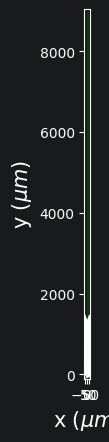

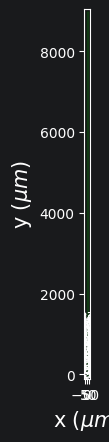

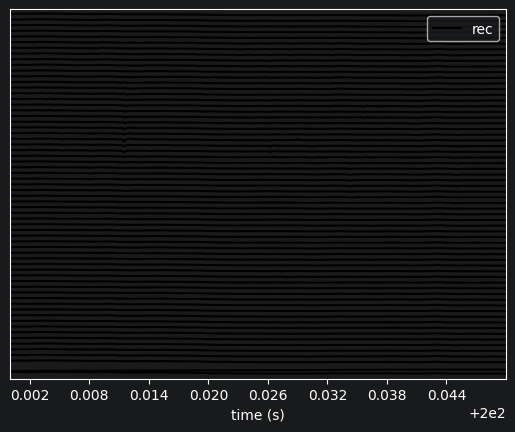

In [3]:
if run_spike_sorting:

    # Load recording and probe, preprocess and fill channel indices from Neuroscope
    recording = si.read_openephys(rec_path, stream_id='0')
    probe = pi.get_probe(manufacturer=probe_manufacturer, probe_name=probe_name) # pi.list_all_probes() to list all probes

    recording = woodsort.openephys.process_with_neuroscope(
        recording=recording,
        probe_or_probegroup=probe,
        session_path=rec_path,
        save_path=processed_path,
        shank_groups=shank_groups,
        remove_bad_channels=True,  # SET TO TRUE
        plot_probe=True,
        plot_range=[200, 200.05])

    # Run spike sorting
    sorting = si.run_sorter(
        recording=recording,
        sorter_name=sorter,
        remove_existing_folder=True,
        folder=spikesorting_path)

    ## Compute analyzer
    analyzer_metrics = json.load(open(analyzer_metrics_path))
    si.create_sorting_analyzer(
        recording=recording,
        sorting=sorting,
        format="binary_folder",
        folder=analyzer_path,
        overwrite=True,
    ).compute(analyzer_metrics)

In [5]:
### Manual curation ###

analyzer = si.load_sorting_analyzer(analyzer_path)
run_mainwindow(analyzer, mode="desktop", curation=True)


In [ ]:
### Get other data from the recording ###

if extract_data:

    # get epochs
    epochs = woodsort.openephys.get_epochs(
        rec_path,
        save_path=processed_path)

    # get OpenEphys metadata
    woodsort.openephys.get_openephys_metadata(
            data_path,
            save_path=processed_path)


    # Extract LFP
    woodsort.lfp.extract_lfp_openephys(rec_path, save_path=processed_path)


Extracting start and end times: /media/du_lab/DATA/5147_260522/2026-05-22_07-48-56/Record Node 101/experiment1/recording1
Extracting start and end times: /media/du_lab/DATA/5147_260522/2026-05-22_07-48-56/Record Node 101/experiment1/recording2
Extracting start and end times: /media/du_lab/DATA/5147_260522/2026-05-22_07-48-56/Record Node 101/experiment1/recording3
Extracting start and end times: /media/du_lab/DATA/5147_260522/2026-05-22_07-48-56/Record Node 101/experiment1/recording4

Epoch timestamps saved to: /media/du_lab/DATA/5147_260522/Processed/EpochTimestamps.csv


Sync metadata written to: /media/du_lab/DATA/5147_260522/Processed/MetadataOpenephys.txt


[1] recording folder: /media/du_lab/DATA/5147_260522/2026-05-22_07-48-56/Record Node 101/experiment1/recording1


Extracting LFP: 100%|██████████| 1082/1082 [02:00<00:00,  8.96it/s]



[2] recording folder: /media/du_lab/DATA/5147_260522/2026-05-22_07-48-56/Record Node 101/experiment1/recording2


Extracting LFP: 100%|██████████| 1096/1096 [02:01<00:00,  8.99it/s]



[3] recording folder: /media/du_lab/DATA/5147_260522/2026-05-22_07-48-56/Record Node 101/experiment1/recording3


Extracting LFP: 100%|██████████| 1101/1101 [02:02<00:00,  8.98it/s]



[4] recording folder: /media/du_lab/DATA/5147_260522/2026-05-22_07-48-56/Record Node 101/experiment1/recording4


Extracting LFP:  70%|███████   | 482/687 [00:53<00:22,  9.07it/s]